In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_df = pd.read_csv(r"C:\Users\prane\OneDrive\Documents\NareshIt\Data_Files\Visadataset.csv")

In [3]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [4]:
cat_data = visa_df.select_dtypes(include='object').columns
num_data = visa_df.select_dtypes(exclude='object').columns

- we have two types of scaling

    - Z Score(Standardization)

    - Min Max Scaler

<img src="https://www.simplypsychology.org/wp-content/uploads/Z-score-formula.jpg" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 435px; height: 226px; margin: 0px; width: 277px;" alt="Z-Score: Definition, Formula, Calculation &amp; Interpretation" jsname="kn3ccd">

In [5]:
# Step1 : take pwage data
# Step2 : calculate mean of data
# Step3 : calculate std of data
# Step4 : NR = data-mean = step1-step2
# Step5 : z_wage = NR/step3
# Step6 : Create a new column visa_df[z_wage'] = z_wage

In [6]:
pwage_data = visa_df['prevailing_wage']

In [17]:
Mean_pwage = np.mean(pwage_data)
Mean_pwage

np.float64(74455.81459209183)

In [16]:
Std_pwage = np.std(pwage_data)
Std_pwage

52814.90589711402

In [18]:
Numerator = pwage_data - Mean_pwage
Numerator

0        -73863.611692
1          8969.835408
2         48541.045408
3          8978.215408
4         75451.575408
             ...      
25475      2636.755408
25476    204718.975408
25477     71843.035408
25478     11698.955408
25479     -3578.904592
Name: prevailing_wage, Length: 25480, dtype: float64

In [20]:
z_wage = Numerator / Std_pwage
z_wage

0       -1.398537
1        0.169835
2        0.919079
3        0.169994
4        1.428604
           ...   
25475    0.049924
25476    3.876159
25477    1.360280
25478    0.221509
25479   -0.067763
Name: prevailing_wage, Length: 25480, dtype: float64

In [21]:
visa_df['z_wage'] = z_wage

In [22]:
visa_df[['prevailing_wage','z_wage']]

,prevailing_wage,z_wage
0,592.2029,-1.398537
1,83425.6500,0.169835
2,122996.8600,0.919079
3,83434.0300,0.169994
4,149907.3900,1.428604
...,...,...
25475,77092.5700,0.049924
25476,279174.7900,3.876159
25477,146298.8500,1.360280
25478,86154.7700,0.221509


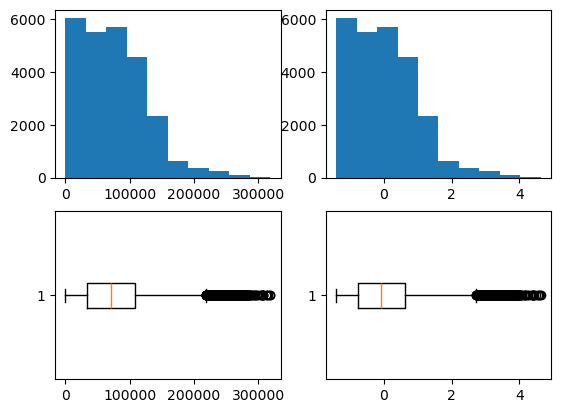

In [28]:
plt.subplot(2,2,1).hist(visa_df['prevailing_wage'])
plt.subplot(2,2,2).hist(visa_df['z_wage'])
plt.subplot(2,2,3).boxplot(visa_df['prevailing_wage'],vert=False)
plt.subplot(2,2,4).boxplot(visa_df['z_wage'],vert=False)
plt.show()

**Standard Scaler**

- sklearn

    - preprocessing
 
        - StandardScalar

In [31]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
Scaler.fit_transform(visa_df['prevailing_wage'])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [34]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
wage_scaled = Scaler.fit_transform(visa_df[['prevailing_wage']])
visa_df['wage_scaled'] = wage_scaled

In [37]:
visa_df[['wage_scaled']]

,wage_scaled
0,-1.398537
1,0.169835
2,0.919079
3,0.169994
4,1.428604
...,...
25475,0.049924
25476,3.876159
25477,1.360280
25478,0.221509


In [38]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,z_wage,wage_scaled
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,-1.398537,-1.398537
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,0.169835,0.169835
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,0.919079,0.919079
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0.169994,0.169994
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1.428604,1.428604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,0.049924,0.049924
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,3.876159,3.876159
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,1.360280,1.360280
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,0.221509,0.221509


In [39]:
visa_df[['prevailing_wage','z_wage','wage_scaled']]

,prevailing_wage,z_wage,wage_scaled
0,592.2029,-1.398537,-1.398537
1,83425.6500,0.169835,0.169835
2,122996.8600,0.919079,0.919079
3,83434.0300,0.169994,0.169994
4,149907.3900,1.428604,1.428604
...,...,...,...
25475,77092.5700,0.049924,0.049924
25476,279174.7900,3.876159,3.876159
25477,146298.8500,1.360280,1.360280
25478,86154.7700,0.221509,0.221509


In [42]:
visa_df
visa_df['prevailing_wage']
visa_df['prevailing_wage'].reshape(-1,1)

AttributeError: 'Series' object has no attribute 'reshape'

In [44]:
visa_df
visa_df['prevailing_wage']
visa_df['prevailing_wage'].values
visa_df['prevailing_wage'].values.reshape(-1,1)

array([[   592.2029],
       [ 83425.65  ],
       [122996.86  ],
       ...,
       [146298.85  ],
       [ 86154.77  ],
       [ 70876.91  ]])

In [45]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
wage_ss = Scaler.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))
wage_ss

array([[-1.39853722],
       [ 0.1698353 ],
       [ 0.91907852],
       ...,
       [ 1.36027953],
       [ 0.22150859],
       [-0.06776315]])

**Min Max Scaler**

<img src="https://miro.medium.com/v2/resize:fit:888/1*ye1I00S61GqpR34ABZZFLQ.png" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 444px; height: 107px; margin: 6px 0px; width: 305px;" alt="How Min-Max Scaler Works. The math behind the min-max scaler | by Kamlesh  Kumar Rangi | Medium" jsname="kn3ccd">

In [48]:
pwage_data = visa_df['prevailing_wage']

In [49]:
Min = pwage_data.min()
Min

2.1367

In [50]:
Max = pwage_data.max()
Max

319210.27

In [51]:
Nr = pwage_data - Min
Nr

0           590.0662
1         83423.5133
2        122994.7233
3         83431.8933
4        149905.2533
            ...     
25475     77090.4333
25476    279172.6533
25477    146296.7133
25478     86152.6333
25479     70874.7733
Name: prevailing_wage, Length: 25480, dtype: float64

In [52]:
Dr = Max - Min
Dr

319208.13330000004

In [53]:
wage_min_max = Nr/Dr
wage_min_max

0        0.001849
1        0.261345
2        0.385312
3        0.261371
4        0.469616
           ...   
25475    0.241505
25476    0.874579
25477    0.458311
25478    0.269895
25479    0.222033
Name: prevailing_wage, Length: 25480, dtype: float64

In [54]:
# all in one
pwage_data = visa_df['prevailing_wage']
Min = pwage_data.min()
Max = pwage_data.max()
Nr = pwage_data - Min
Dr = Max - Min
wage_min_max = Nr/Dr
visa_df['wage_min_max'] = wage_min_max

In [55]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,z_wage,wage_scaled,wage_min_max
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,-1.398537,-1.398537,0.001849
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,0.169835,0.169835,0.261345
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,0.919079,0.919079,0.385312
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0.169994,0.169994,0.261371
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1.428604,1.428604,0.469616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,0.049924,0.049924,0.241505
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,3.876159,3.876159,0.874579
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,1.360280,1.360280,0.458311
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,0.221509,0.221509,0.269895


**Another approach**

In [57]:
from sklearn.preprocessing import MinMaxScaler
MinMax = MinMaxScaler()
MinMax.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))

array([[0.00184853],
       [0.2613452 ],
       [0.385312  ],
       ...,
       [0.45831136],
       [0.26989486],
       [0.22203311]])

In [58]:
from sklearn.preprocessing import MinMaxScaler
MinMax = MinMaxScaler()
Wage_Min_Max = MinMax.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))
visa_df['Wage_Min_Max'] = Wage_Min_Max
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,z_wage,wage_scaled,wage_min_max,Wage_Min_Max
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,-1.398537,-1.398537,0.001849,0.001849
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,0.169835,0.169835,0.261345,0.261345
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,0.919079,0.919079,0.385312,0.385312
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0.169994,0.169994,0.261371,0.261371
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1.428604,1.428604,0.469616,0.469616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,0.049924,0.049924,0.241505,0.241505
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,3.876159,3.876159,0.874579,0.874579
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,1.360280,1.360280,0.458311,0.458311
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,0.221509,0.221509,0.269895,0.269895
